In [3]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


# 1. SETUP

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

# 2. CONFIG

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Sesuaikan kemampuan GPU

TRAIN_DIR = "data/processed/train"
VAL_DIR   = "data/processed/validation"
TEST_DIR  = "data/processed/test"

EPOCHS = 30 # Bisa diubah
FINE_TUNE_EPOCHS = 15 # Epoch untuk fine-tuning

INITIAL_LR = 1e-4 # Learning rate di 0.0001
FINE_TUNE_LR = 1e-5 # Learning rate di 0.00001 untuk fine-tuning

# Kontrol training: default jalankan full epoch (tanpa stop otomatis)
USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 7
EARLY_STOP_START_EPOCH = 3

# 3. LOAD DATASET

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalisasi dataset ke rentang [0, 1] sebelum masuk ke model
train_gen = ImageDataGenerator(rescale=1.0 / 255.0)
val_test_gen = ImageDataGenerator(rescale=1.0 / 255.0)

# Membuat generator untuk data train
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data validasi
val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data test
test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 240 images belonging to 4 classes.
Found 240 images belonging to 4 classes.


# 4. CALLBACK

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("models/best_model.h5", save_best_only=True),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

# EarlyStopping opsional: aktifkan jika ingin hentikan training otomatis
if USE_EARLY_STOPPING:
    callbacks.append(
        EarlyStopping(
            monitor='val_loss',
            patience=EARLY_STOP_PATIENCE,
            start_from_epoch=EARLY_STOP_START_EPOCH,
            restore_best_weights=True,
            verbose=1,
        )
    )

# 5. FUNCTION EVALUASI

In [8]:
def _collect_full_test_set(generator):
    generator.reset()
    x_batches, y_batches = [], []
    for _ in range(len(generator)):
        x_batch, y_batch = next(generator)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis=0)
    y_true = np.argmax(np.concatenate(y_batches, axis=0), axis=1)
    return x_test, y_true

def evaluate_model(model, model_name, return_details=False, show_plot=True):
    print(f"\n=== {model_name} ===")

    # Evaluasi loss/akurasi pada test generator
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose=0)
    print("Accuracy:", acc)
    print("Loss:", loss)

    # Prediksi menggunakan array penuh agar bentuk tensor konsisten
    x_test, y_true = _collect_full_test_set(test_data)
    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    class_names = [
        name
        for name, _ in sorted(test_data.class_indices.items(), key=lambda item: item[1])
    ]

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    print("\nClassification Report:")
    print(report_text)

    cm = confusion_matrix(y_true, y_pred)
    if show_plot:
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    if return_details:
        return {
            "model_name": model_name,
            "accuracy": float(acc),
            "loss": float(loss),
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "class_names": class_names,
            "report_dict": report_dict,
            "confusion_matrix": cm,
        }

    return acc

# 6. MODEL

## A. MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Membangun MobileNetV2 sebagai base model
def build_mobilenet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    # Data sudah dinormalisasi [0, 1], kembalikan ke [0, 255] sebelum preprocess_input
    x = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)

    base = MobileNetV2(weights=None, include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## B. EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# Membangun EfficientNetB0 sebagai base model
def build_efficientnet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    x = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base = EfficientNetB0(weights=None, include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## C. Hybrid (Feature Fusion)

In [ ]:
def build_fusion():
    input_layer = tf.keras.Input(shape=(224, 224, 3))

    # Dataset sudah [0,1], ubah dulu ke [0,255] agar preprocessing backbone sesuai
    mob_in = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)
    eff_in = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base1 = MobileNetV2(weights=None, include_top=False, input_tensor=mob_in)
    base2 = EfficientNetB0(weights=None, include_top=False, input_tensor=eff_in)

    base1.trainable = False
    base2.trainable = False

    x1 = layers.GlobalAveragePooling2D()(base1.output)
    x1 = layers.BatchNormalization()(x1)

    x2 = layers.GlobalAveragePooling2D()(base2.output)
    x2 = layers.BatchNormalization()(x2)

    fusion = layers.concatenate([x1, x2])

    x = layers.Dense(256, activation='relu')(fusion)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base1, base2

# 7. Training Function (2 Tahap)

In [12]:
import time

def train_model(model, base_model=None):
    # Tahap 1
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    stage1_start = time.perf_counter()
    history_stage1 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    stage1_time = time.perf_counter() - stage1_start

    # Tahap 2 (Fine-tuning)
    if base_model is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-80]:
            layer.trainable = False
        for layer in base_model.layers[-80:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    stage2_start = time.perf_counter()
    history_stage2 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks
    )
    stage2_time = time.perf_counter() - stage2_start

    history_bundle = {
        "stage1": history_stage1.history,
        "stage2": history_stage2.history,
    }
    timing_bundle = {
        "stage1_sec": stage1_time,
        "stage2_sec": stage2_time,
        "total_sec": stage1_time + stage2_time,
    }

    return model, history_bundle, timing_bundle

# 8. Train & Evaluasi Model

## A. MobileNetV2

C:\Users\rifqi\AppData\Local\Temp\ipykernel_15748\528472138.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.3556 - loss: 1.6934

140/140 ━━━━━━━━━━━━━━━━━━━━ 92s 622ms/step - accuracy: 0.4413 - loss: 1.4502 - val_accuracy: 0.6500 - val_loss: 0.8798 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.6148 - loss: 0.9840

140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 257ms/step - accuracy: 0.6460 - loss: 0.9219 - val_accuracy: 0.7125 - val_loss: 0.7251 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.6877 - loss: 0.7951

140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 256ms/step - accuracy: 0.7076 - loss: 0.7601 - val_accuracy: 0.7667 - val_loss: 0.6896 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7542 - loss: 0.6353

...

140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 480ms/step - accuracy: 0.9087 - loss: 0.2345 - val_accuracy: 0.8292 - val_loss: 0.4772 - learning_rate: 5.0000e-06
Epoch 9/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9175 - loss: 0.2278

140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 476ms/step - accuracy: 0.9214 - loss: 0.2114 - val_accuracy: 0.8333 - val_loss: 0.4691 - learning_rate: 5.0000e-06
Epoch 10/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9218 - loss: 0.2104

140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 476ms/step - accuracy: 0.9205 - loss: 0.2121 - val_accuracy: 0.8375 - val_loss: 0.4553 - learning_rate: 5.0000e-06
Epoch 11/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9386 - loss: 0.1764

140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 470ms/step - accuracy: 0.9371 - loss: 0.1808 - val_accuracy: 0.8458 - val_loss: 0.4434 - learning_rate: 5.0000e-06
Epoch 12/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 468ms/step - accuracy: 0.9435 - loss: 0.1683 - val_accuracy: 0.8542 - val_loss: 0.4496 - learning_rate: 5.0000e-06
Epoch 13/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 475ms/step - accuracy: 0.9451 - loss: 0.1553 - val_accuracy: 0.8500 - val_loss: 0.4534 - learning_rate: 5.0000e-06
Epoch 14/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9534 - loss: 0.1272

140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 475ms/step - accuracy: 0.9536 - loss: 0.1293 - val_accuracy: 0.8542 - val_loss: 0.4421 - learning_rate: 5.0000e-06
Epoch 15/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 470ms/step - accuracy: 0.9540 - loss: 0.1318 - val_accuracy: 0.8625 - val_loss: 0.4461 - learning_rate: 5.0000e-06

=== MobileNetV2 ===
Accuracy: 0.7916666865348816
Loss: 0.6320935487747192

Classification Report:
              precision    recall  f1-score   support

healthy leaf       0.84      0.77      0.80        61
   leaf curl       0.75      0.79      0.77        57
   leaf spot       0.83      0.92      0.87        60
   yellowish       0.74      0.69      0.72        62

    accuracy                           0.79       240
   macro avg       0.79      0.79      0.79       240
weighted avg       0.79      0.79      0.79       240



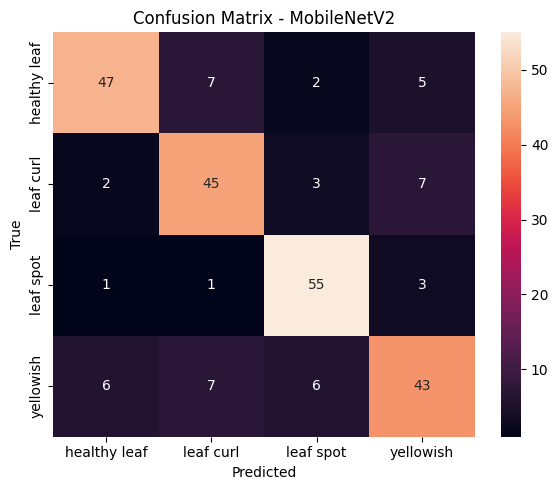

In [13]:
model_m, base_m = build_mobilenet()
model_m, history_m, timing_m = train_model(model_m, base_m)
eval_m = evaluate_model(model_m, "MobileNetV2", return_details=True)
acc_m = eval_m["accuracy"]

## B. EfficientNetB0

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 403ms/step - accuracy: 0.4563 - loss: 1.4593 - val_accuracy: 0.6667 - val_loss: 0.9210 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 381ms/step - accuracy: 0.6433 - loss: 0.9346 - val_accuracy: 0.7417 - val_loss: 0.6704 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.6963 - loss: 0.8115
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 388ms/step - accuracy: 0.7112 - loss: 0.7587 - val_accuracy: 0.7875 - val_loss: 0.5463 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 380ms/step - accuracy: 0.7475 - loss: 0.6569 - val_accuracy: 0.7917 - val_loss: 0.5013 - learning_rate: 5.0000e-05
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 389ms/step - accuracy: 0.7641 - loss: 0.6117 - val_accuracy: 0.7875 - val_loss: 0.4843 - learning_rate: 5.0000e-05
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/ste

140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 378ms/step - accuracy: 0.8183 - loss: 0.4750 - val_accuracy: 0.8042 - val_loss: 0.4414 - learning_rate: 1.2500e-05
Epoch 12/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8214 - loss: 0.4593

140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 384ms/step - accuracy: 0.8250 - loss: 0.4608 - val_accuracy: 0.8042 - val_loss: 0.4399 - learning_rate: 1.2500e-05
Epoch 13/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.8286 - loss: 0.4547

140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 382ms/step - accuracy: 0.8308 - loss: 0.4493 - val_accuracy: 0.8083 - val_loss: 0.4344 - learning_rate: 1.2500e-05
Epoch 14/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.8295 - loss: 0.4685

140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 387ms/step - accuracy: 0.8281 - loss: 0.4614 - val_accuracy: 0.8000 - val_loss: 0.4318 - learning_rate: 1.2500e-05
Epoch 15/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.8407 - loss: 0.4287

...

140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 380ms/step - accuracy: 0.8455 - loss: 0.3998 - val_accuracy: 0.8333 - val_loss: 0.4128 - learning_rate: 1.2500e-05
Epoch 24/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 380ms/step - accuracy: 0.8460 - loss: 0.4039 - val_accuracy: 0.8333 - val_loss: 0.4140 - learning_rate: 1.2500e-05
Epoch 25/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.8559 - loss: 0.3811

140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 386ms/step - accuracy: 0.8493 - loss: 0.3978 - val_accuracy: 0.8417 - val_loss: 0.4105 - learning_rate: 1.2500e-05
Epoch 26/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.8470 - loss: 0.4026

140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 378ms/step - accuracy: 0.8569 - loss: 0.3848 - val_accuracy: 0.8375 - val_loss: 0.4091 - learning_rate: 1.2500e-05
Epoch 27/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.8509 - loss: 0.3946

140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 385ms/step - accuracy: 0.8518 - loss: 0.3928 - val_accuracy: 0.8458 - val_loss: 0.4055 - learning_rate: 1.2500e-05
Epoch 28/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8662 - loss: 0.3628

140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 377ms/step - accuracy: 0.8647 - loss: 0.3702 - val_accuracy: 0.8458 - val_loss: 0.4038 - learning_rate: 1.2500e-05
Epoch 29/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 381ms/step - accuracy: 0.8701 - loss: 0.3660 - val_accuracy: 0.8417 - val_loss: 0.4055 - learning_rate: 1.2500e-05
Epoch 30/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 385ms/step - accuracy: 0.8694 - loss: 0.3496 - val_accuracy: 0.8542 - val_loss: 0.4057 - learning_rate: 1.2500e-05
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 102s 618ms/step - accuracy: 0.6172 - loss: 1.0100 - val_accuracy: 0.7750 - val_loss: 0.5661 - learning_rate: 1.0000e-05
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 575ms/step - accuracy: 0.6993 - loss: 0.7790 - val_accuracy: 0.8000 - val_loss: 0.5606 - learning_rate: 1.0000e-05
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.7184 - loss: 0.7191
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 575ms/step - acc

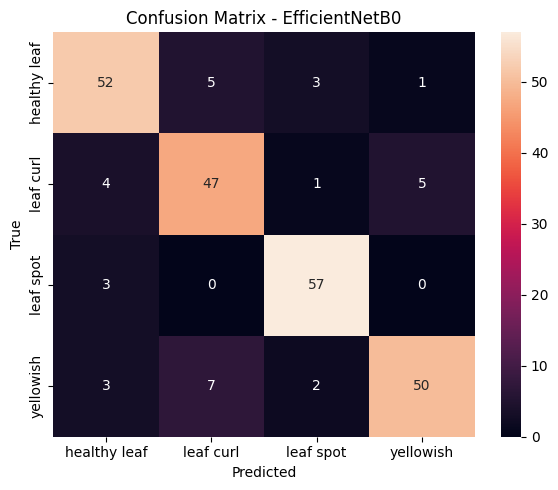

In [14]:
model_e, base_e = build_efficientnet()
model_e, history_e, timing_e = train_model(model_e, base_e)
eval_e = evaluate_model(model_e, "EfficientNetB0", return_details=True)
acc_e = eval_e["accuracy"]

## C. Hybrid Model

C:\Users\rifqi\AppData\Local\Temp\ipykernel_15748\3286220957.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 95s 598ms/step - accuracy: 0.5884 - loss: 1.1911 - val_accuracy: 0.7458 - val_loss: 0.6714 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 571ms/step - accuracy: 0.7879 - loss: 0.5792 - val_accuracy: 0.7833 - val_loss: 0.5497 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.8331 - loss: 0.4549
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 574ms/step - accuracy: 0.8471 - loss: 0.4097 - val_accuracy: 0.8083 - val_loss: 0.5132 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 572ms/step - accuracy: 0.8888 - loss: 0.2962 - val_accuracy: 0.8208 - val_loss: 0.4919 - learning_rate: 5.0000e-05
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 573ms/step - accuracy: 0.8960 - loss: 0.2817 - val_accuracy: 0.8083 - val_loss: 0.4938 - learning_rate: 5.0000e-05
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/ste


Classification Report:
              precision    recall  f1-score   support

healthy leaf       0.87      0.85      0.86        61
   leaf curl       0.76      0.79      0.78        57
   leaf spot       0.88      0.95      0.91        60
   yellowish       0.80      0.73      0.76        62

    accuracy                           0.83       240
   macro avg       0.83      0.83      0.83       240
weighted avg       0.83      0.83      0.83       240



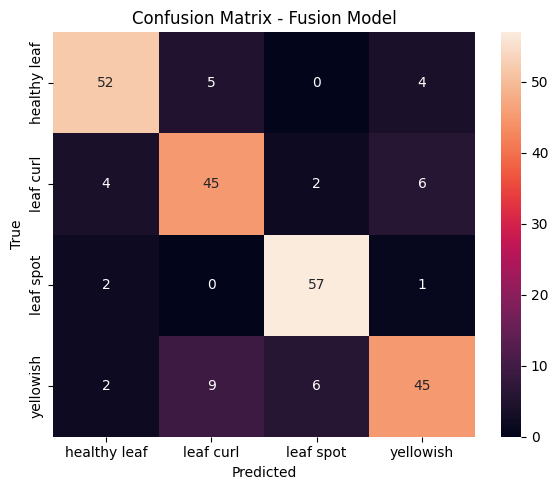

In [15]:
model_f, base1, base2 = build_fusion()

# Tahap 1
model_f.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
 )
hybrid_stage1_start = time.perf_counter()
history_f_stage1 = model_f.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
 )
hybrid_stage1_time = time.perf_counter() - hybrid_stage1_start

# Fine-tuning dua backbone
for layer in base1.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
for layer in base2.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model_f.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
 )
hybrid_stage2_start = time.perf_counter()
history_f_stage2 = model_f.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks
 )
hybrid_stage2_time = time.perf_counter() - hybrid_stage2_start

history_f = {
    "stage1": history_f_stage1.history,
    "stage2": history_f_stage2.history,
}
timing_f = {
    "stage1_sec": hybrid_stage1_time,
    "stage2_sec": hybrid_stage2_time,
    "total_sec": hybrid_stage1_time + hybrid_stage2_time,
}

eval_f = evaluate_model(model_f, "Fusion Model", return_details=True)
acc_f = eval_f["accuracy"]

# 9. Perbandingan Hasil

In [16]:
print("\n=== HASIL AKHIR ===")
print(f"MobileNetV2   : {acc_m}")
print(f"EfficientNet  : {acc_e}")
print(f"Fusion Model  : {acc_f}")


=== HASIL AKHIR ===
MobileNetV2   : 0.7916666865348816
EfficientNet  : 0.8583333492279053
Fusion Model  : 0.8291666507720947


# 10. Visualisasi Hasil dan Performa 3 Model

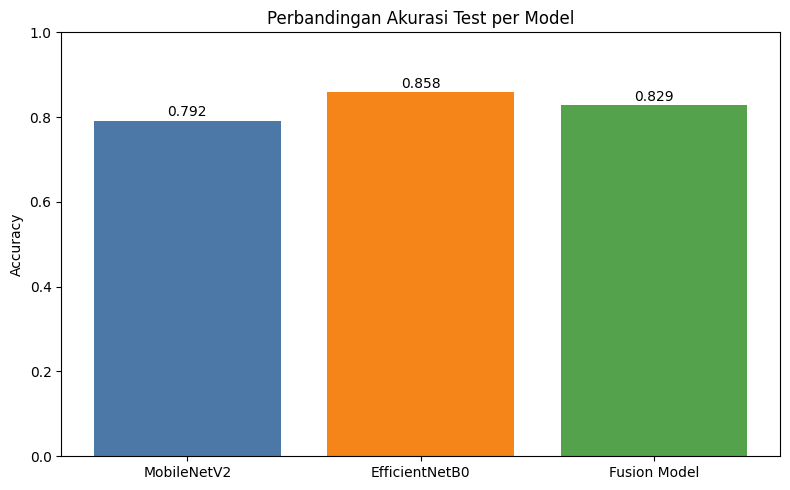

Model akurasi tertinggi: EfficientNetB0 (0.8583)
Peningkatan Hybrid vs MobileNetV2: +3.75%


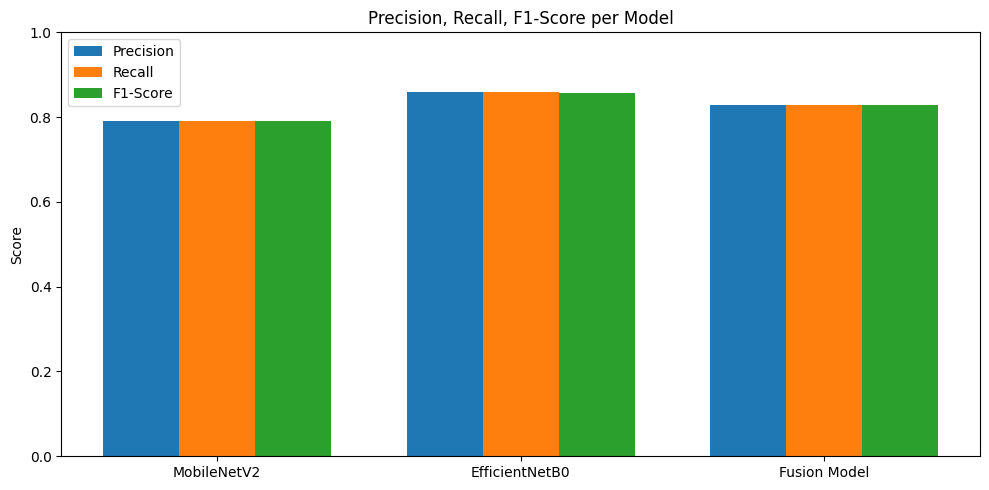

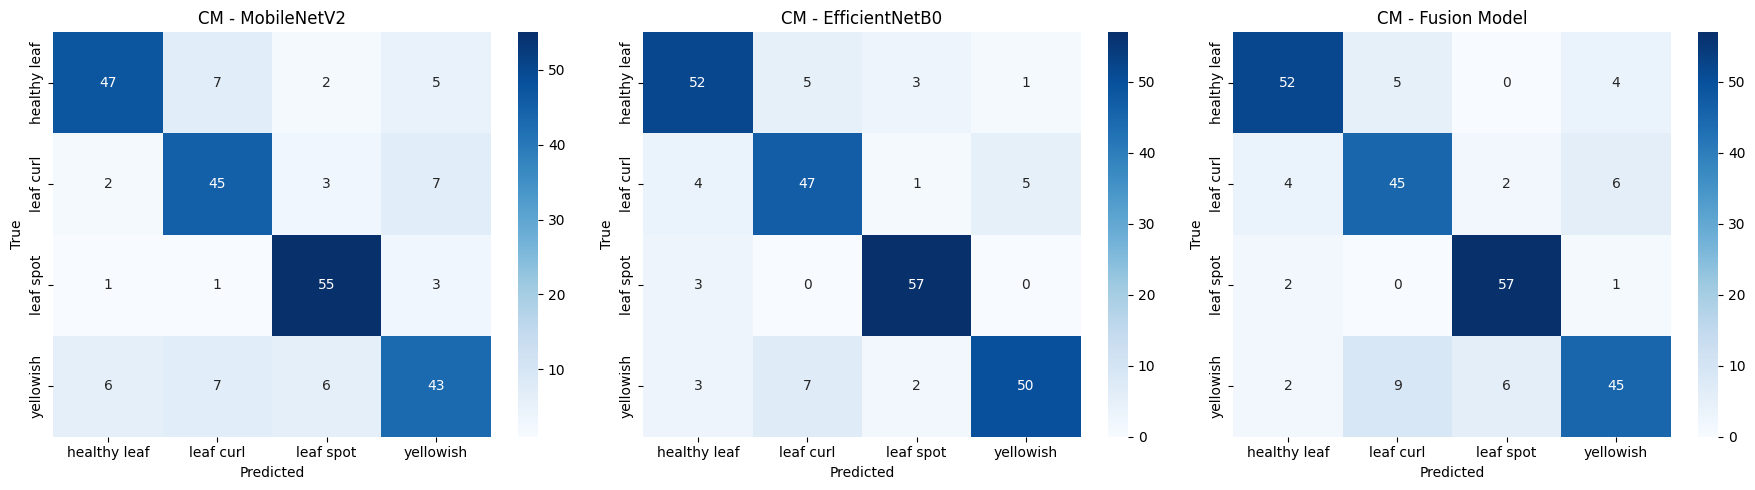

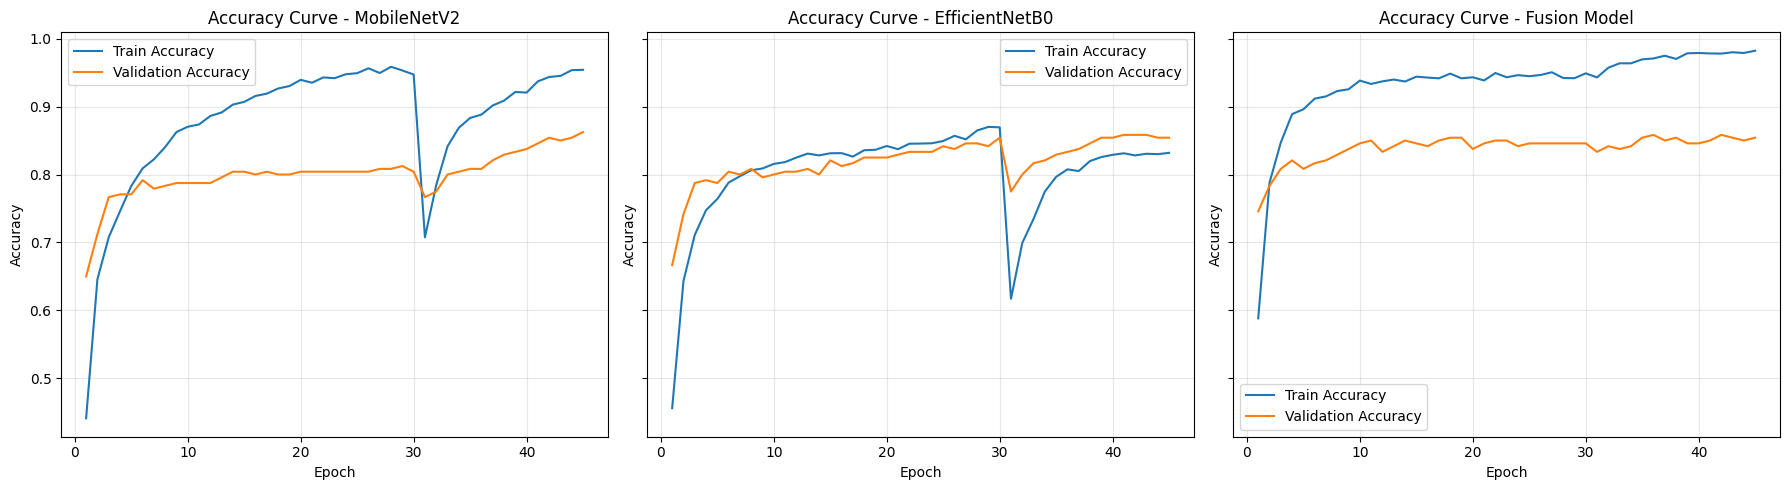

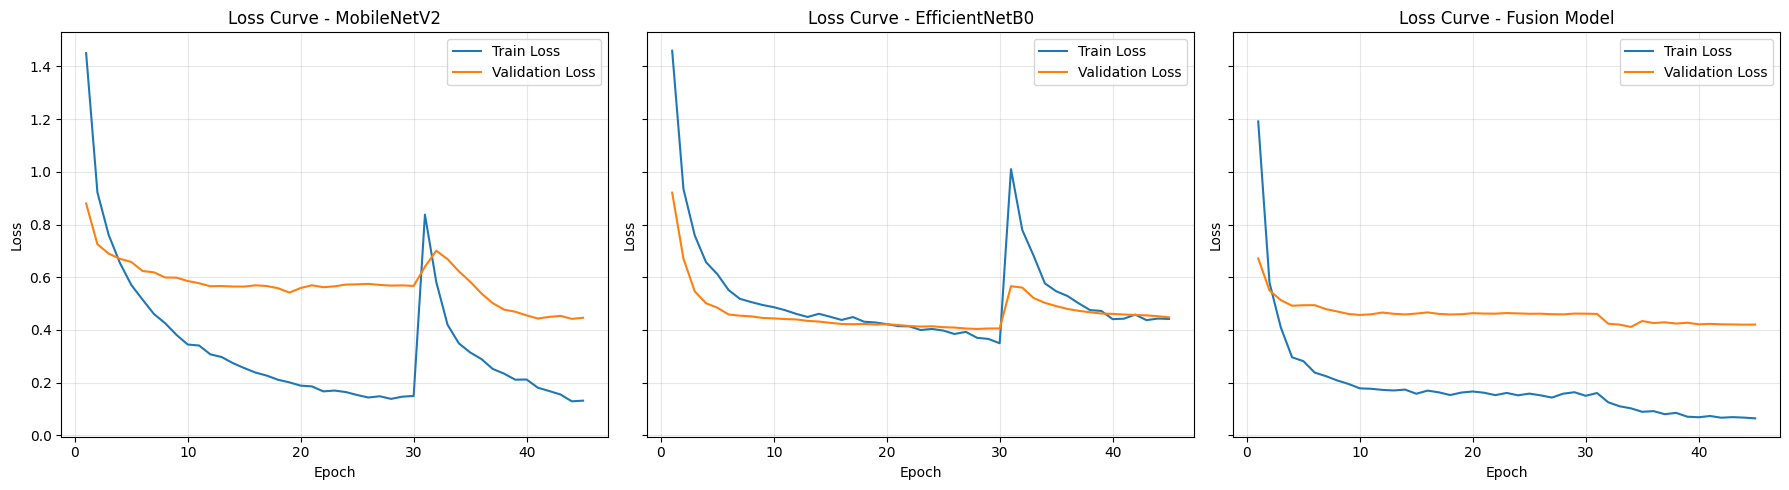

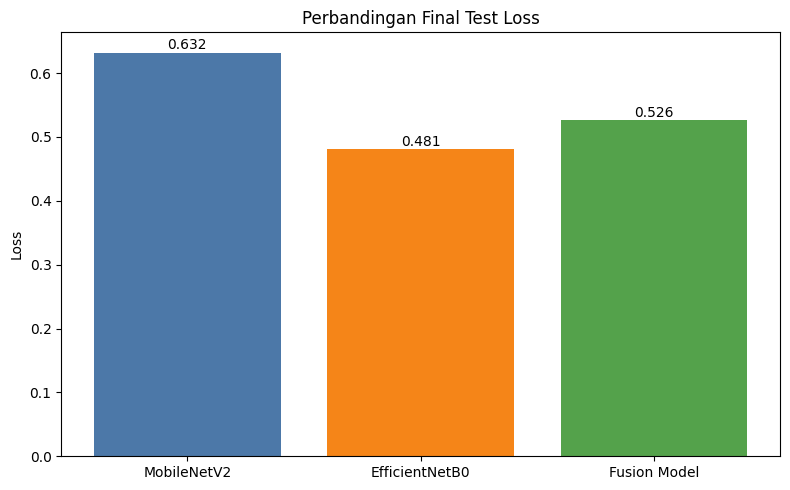

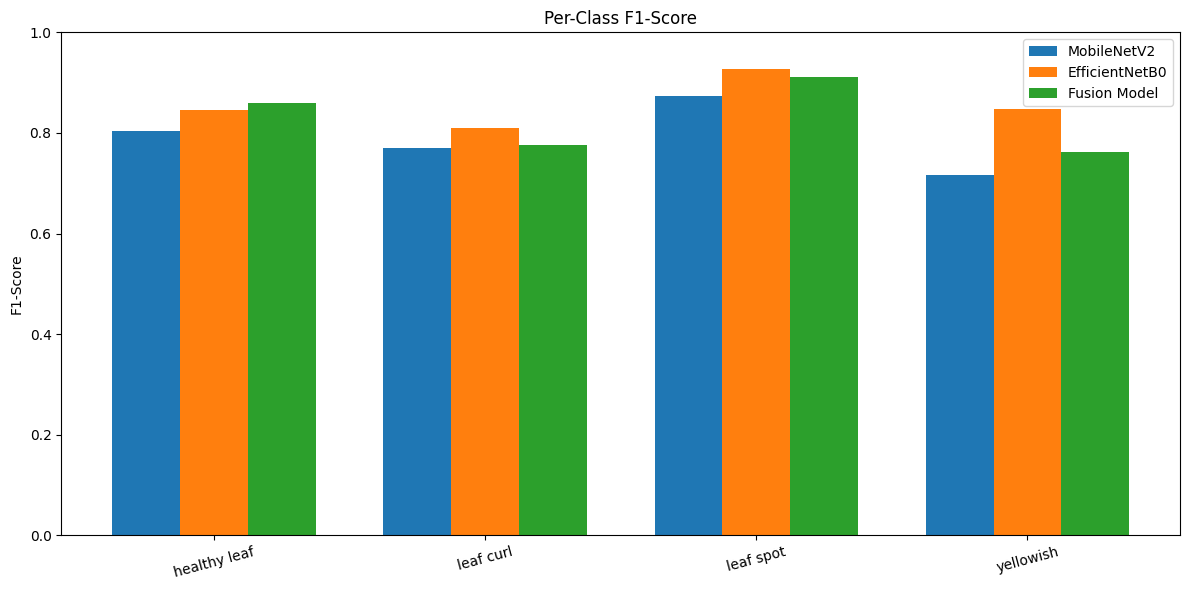

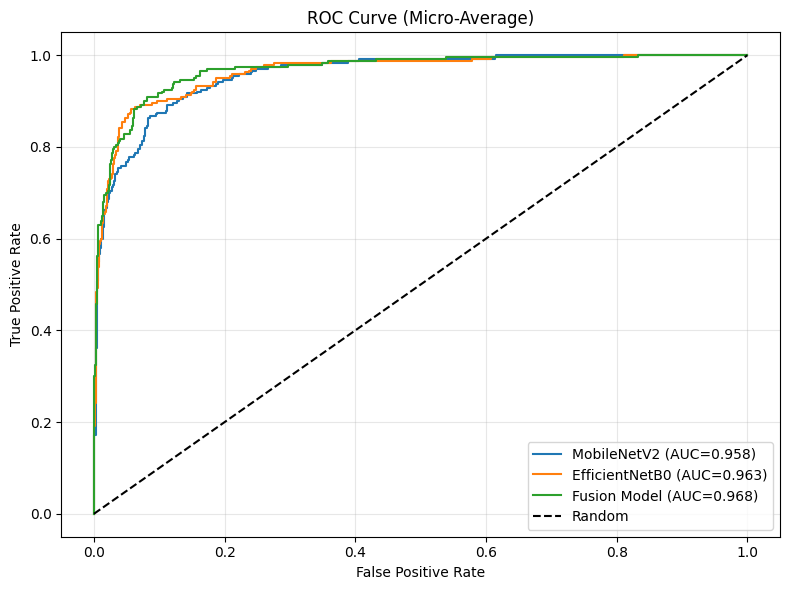

,Model,Accuracy,Precision,Recall,F1-Score,Test Loss,AUC,Training Time (sec)
1,EfficientNetB0,0.8583,0.8592,0.8583,0.8580,0.4813,0.9634,2852.2781
2,Fusion Model,0.8292,0.8282,0.8292,0.8278,0.5259,0.9680,3784.9447
0,MobileNetV2,0.7917,0.7913,0.7917,0.7903,0.6321,0.9577,2136.1003


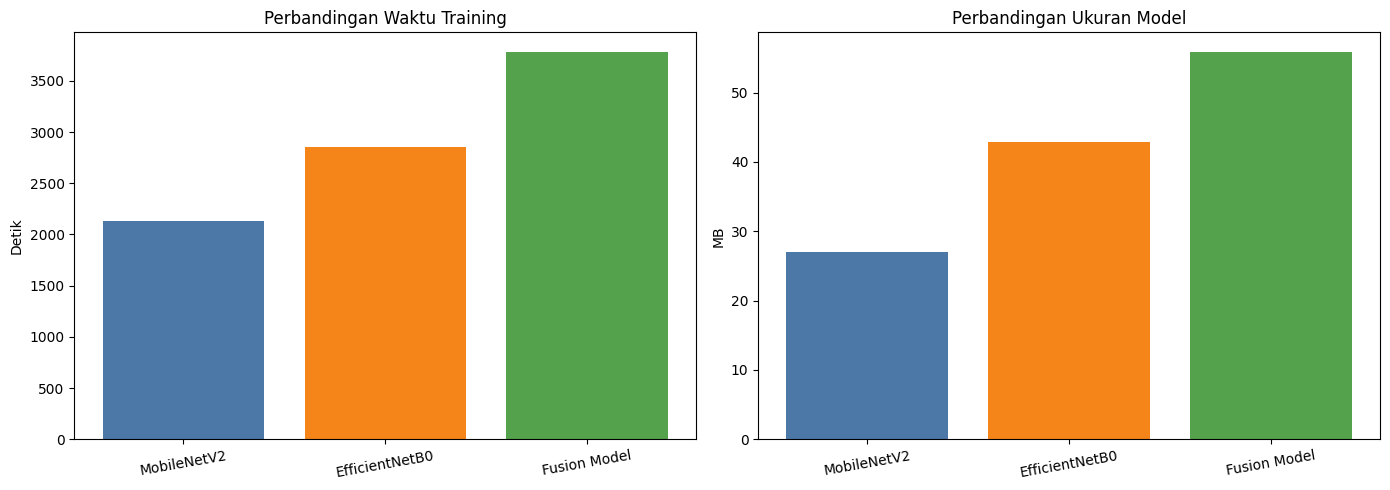


Insight cepat:
- Akurasi tertinggi: EfficientNetB0
- Gain Hybrid vs MobileNetV2: +3.75%
- Cek gap train vs validation untuk indikasi overfitting.
- Cek confusion matrix untuk kelas yang masih sering tertukar.


In [17]:
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

# Pastikan model tersedia di kernel
required_models = ["model_m", "model_e", "model_f"]
missing_models = [name for name in required_models if name not in globals()]
if missing_models:
    raise ValueError(
        "Model belum tersedia di kernel. Jalankan dulu cell 23, 25, dan 27. "
        f"Missing: {missing_models}"
    )

def build_eval_details(model, model_name):
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose=0)

    test_data.reset()
    x_batches, y_batches = [], []
    for _ in range(len(test_data)):
        x_batch, y_batch = next(test_data)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis=0)
    y_true = np.argmax(np.concatenate(y_batches, axis=0), axis=1)
    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    class_names_local = [
        name for name, _ in sorted(test_data.class_indices.items(), key=lambda item: item[1])
    ]

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names_local,
        zero_division=0,
        output_dict=True,
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model_name": model_name,
        "accuracy": float(acc),
        "loss": float(loss),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "class_names": class_names_local,
        "report_dict": report_dict,
        "confusion_matrix": cm,
    }

# Jika detail evaluasi belum ada, hitung otomatis
if "eval_m" not in globals():
    eval_m = build_eval_details(model_m, "MobileNetV2")
if "eval_e" not in globals():
    eval_e = build_eval_details(model_e, "EfficientNetB0")
if "eval_f" not in globals():
    eval_f = build_eval_details(model_f, "Fusion Model")

model_results = {
    "MobileNetV2": eval_m,
    "EfficientNetB0": eval_e,
    "Fusion Model": eval_f,
}

history_available = all(name in globals() for name in ["history_m", "history_e", "history_f"])
timing_available = all(name in globals() for name in ["timing_m", "timing_e", "timing_f"])

if history_available:
    model_histories = {
        "MobileNetV2": history_m,
        "EfficientNetB0": history_e,
        "Fusion Model": history_f,
    }
else:
    print("Info: history_* belum ada, grafik accuracy/loss curve tidak ditampilkan.")

if timing_available:
    model_timings = {
        "MobileNetV2": timing_m,
        "EfficientNetB0": timing_e,
        "Fusion Model": timing_f,
    }
else:
    print("Info: timing_* belum ada, perbandingan waktu training tidak ditampilkan.")

class_names = eval_m["class_names"]

def merge_history(history_bundle):
    train_acc = history_bundle["stage1"].get("accuracy", []) + history_bundle["stage2"].get("accuracy", [])
    val_acc = history_bundle["stage1"].get("val_accuracy", []) + history_bundle["stage2"].get("val_accuracy", [])
    train_loss = history_bundle["stage1"].get("loss", []) + history_bundle["stage2"].get("loss", [])
    val_loss = history_bundle["stage1"].get("val_loss", []) + history_bundle["stage2"].get("val_loss", [])
    return train_acc, val_acc, train_loss, val_loss

def get_model_size_mb(model, filename):
    model.save(filename, include_optimizer=False)
    size_mb = os.path.getsize(filename) / (1024 ** 2)
    os.remove(filename)
    return size_mb

# 1) Perbandingan Akurasi per Model
acc_df = pd.DataFrame({
    "Model": list(model_results.keys()),
    "Accuracy": [v["accuracy"] for v in model_results.values()],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.show()

best_model = acc_df.sort_values("Accuracy", ascending=False).iloc[0]
hybrid_gain_vs_mobilenet = (model_results["Fusion Model"]["accuracy"] - model_results["MobileNetV2"]["accuracy"]) * 100
print(f"Model akurasi tertinggi: {best_model['Model']} ({best_model['Accuracy']:.4f})")
print(f"Peningkatan Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")

# 2) Precision, Recall, F1-Score per Model
metric_rows = []
for model_name, result in model_results.items():
    w = result["report_dict"]["weighted avg"]
    metric_rows.append({
        "Model": model_name,
        "Precision": w["precision"],
        "Recall": w["recall"],
        "F1-Score": w["f1-score"],
    })
metrics_df = pd.DataFrame(metric_rows)

x = np.arange(len(metrics_df))
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, metrics_df["Precision"], width=w, label="Precision")
plt.bar(x, metrics_df["Recall"], width=w, label="Recall")
plt.bar(x + w, metrics_df["F1-Score"], width=w, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Confusion Matrix (3 heatmap)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, result) in zip(axes, model_results.items()):
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(f"CM - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# 4) Training vs Validation Accuracy Curve
if history_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        ax.plot(epochs, train_acc, label="Train Accuracy")
        ax.plot(epochs, val_acc, label="Validation Accuracy")
        ax.set_title(f"Accuracy Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# 5) Training vs Validation Loss Curve
if history_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        ax.plot(epochs, train_loss, label="Train Loss")
        ax.plot(epochs, val_loss, label="Validation Loss")
        ax.set_title(f"Loss Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# 6) Perbandingan Loss Akhir
loss_df = pd.DataFrame({
    "Model": list(model_results.keys()),
    "Final Test Loss": [v["loss"] for v in model_results.values()],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.show()

# 7) F1-score per Kelas (grouped)
per_class_rows = []
for model_name, result in model_results.items():
    for cls in class_names:
        per_class_rows.append({
            "Model": model_name,
            "Class": cls,
            "F1-Score": result["report_dict"][cls]["f1-score"],
        })
per_class_df = pd.DataFrame(per_class_rows)

plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

# 8) ROC Curve + AUC (micro-average multiclass)
auc_scores = {}
plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    y_prob = result["y_prob"]
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Classification Report Table (Ringkasan)
summary_rows = []
for model_name, result in model_results.items():
    w = result["report_dict"]["weighted avg"]
    summary_rows.append({
        "Model": model_name,
        "Accuracy": result["accuracy"],
        "Precision": w["precision"],
        "Recall": w["recall"],
        "F1-Score": w["f1-score"],
        "Test Loss": result["loss"],
        "AUC": auc_scores[model_name],
        "Training Time (sec)": model_timings[model_name]["total_sec"] if timing_available else np.nan,
    })
summary_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending=False)
display(summary_df.round(4))

# 10) Waktu Training dan Ukuran Model
model_sizes_mb = {
    "MobileNetV2": get_model_size_mb(model_m, "tmp_model_m.keras"),
    "EfficientNetB0": get_model_size_mb(model_e, "tmp_model_e.keras"),
    "Fusion Model": get_model_size_mb(model_f, "tmp_model_f.keras"),
}

if timing_available:
    efficiency_df = pd.DataFrame({
        "Model": list(model_timings.keys()),
        "Training Time (sec)": [v["total_sec"] for v in model_timings.values()],
        "Model Size (MB)": [model_sizes_mb[name] for name in model_timings.keys()],
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[0].set_title("Perbandingan Waktu Training")
    axes[0].set_ylabel("Detik")
    axes[0].tick_params(axis='x', rotation=10)

    axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[1].set_title("Perbandingan Ukuran Model")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.show()
else:
    size_df = pd.DataFrame({
        "Model": list(model_sizes_mb.keys()),
        "Model Size (MB)": list(model_sizes_mb.values()),
    })
    plt.figure(figsize=(8, 5))
    plt.bar(size_df["Model"], size_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Perbandingan Ukuran Model")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.show()

print("\nInsight cepat:")
print(f"- Akurasi tertinggi: {summary_df.iloc[0]['Model']}")
print(f"- Gain Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")
print("- Cek gap train vs validation untuk indikasi overfitting.")
print("- Cek confusion matrix untuk kelas yang masih sering tertukar.")

# 11. Export Grafik dan Tabel ke Folder Reports

In [18]:
from pathlib import Path

base_dir = Path.cwd()
fig_dir = base_dir / "reports" / "figures"
metrics_dir = base_dir / "reports" / "metrics"
fig_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# Simpan tabel metrik
acc_df.to_csv(metrics_dir / "accuracy_per_model.csv", index=False)
metrics_df.to_csv(metrics_dir / "precision_recall_f1_per_model.csv", index=False)
loss_df.to_csv(metrics_dir / "final_loss_per_model.csv", index=False)
per_class_df.to_csv(metrics_dir / "f1_per_class_per_model.csv", index=False)
summary_df.to_csv(metrics_dir / "classification_summary_table.csv", index=False)

if "size_df" in globals():
    size_df.to_csv(metrics_dir / "model_size_comparison.csv", index=False)
if "efficiency_df" in globals():
    efficiency_df.to_csv(metrics_dir / "training_time_and_model_size.csv", index=False)

# 1) Accuracy per model
plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "01_accuracy_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

# 2) Precision/Recall/F1 grouped
x = np.arange(len(metrics_df))
width = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - width, metrics_df["Precision"], width=width, label="Precision")
plt.bar(x, metrics_df["Recall"], width=width, label="Recall")
plt.bar(x + width, metrics_df["F1-Score"], width=width, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "02_precision_recall_f1_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

# 3) Confusion matrix per model
for idx, (model_name, result) in enumerate(model_results.items(), start=1):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    filename = f"03_confusion_matrix_{idx}_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
    plt.close()

# 4) Accuracy curve (jika history tersedia)
if "model_histories" in globals():
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_acc, label="Train Accuracy")
        plt.plot(epochs, val_acc, label="Validation Accuracy")
        plt.title(f"Accuracy Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"04_accuracy_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

# 5) Loss curve (jika history tersedia)
if "model_histories" in globals():
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_loss, label="Train Loss")
        plt.plot(epochs, val_loss, label="Validation Loss")
        plt.title(f"Loss Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"05_loss_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

# 6) Final loss comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "06_final_loss_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

# 7) Per-class F1 grouped
plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "07_f1_per_class_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

# 8) ROC curve
plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    y_prob = result["y_prob"]
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "08_roc_curve_micro_average.png", dpi=300, bbox_inches="tight")
plt.close()

# 10) Efficiency chart
if "efficiency_df" in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[0].set_title("Perbandingan Waktu Training")
    axes[0].set_ylabel("Detik")
    axes[0].tick_params(axis='x', rotation=10)

    axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[1].set_title("Perbandingan Ukuran Model")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.savefig(fig_dir / "10_efficiency_time_and_size.png", dpi=300, bbox_inches="tight")
    plt.close()
elif "size_df" in globals():
    plt.figure(figsize=(8, 5))
    plt.bar(size_df["Model"], size_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Perbandingan Ukuran Model")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.savefig(fig_dir / "10_model_size_comparison.png", dpi=300, bbox_inches="tight")
    plt.close()

print(f"Export selesai: {fig_dir}")
print(f"Export selesai: {metrics_dir}")

Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\figures
Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\metrics
